In [ ]:
!pip install wfdb numpy scipy matplotlib pandas pywavelets pyswarms

Sampling rate: 360 Hz
Number of samples: 3600
Channels: ['MLII', 'V5']
First 5 beat positions: [ 18  77 370 662 946]
First 5 beat labels: ['+', 'N', 'N', 'N', 'N']


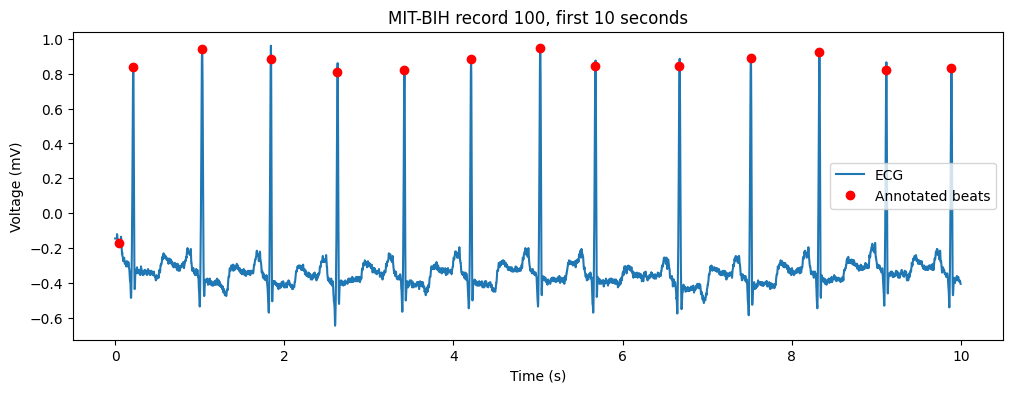

In [ ]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=3600)
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb', sampto=3600)

signal = record.p_signal[:, 0]
fs = record.fs
time = [i / fs for i in range(len(signal))]

print("Sampling rate:", fs, "Hz")
print("Number of samples:", len(signal))
print("Channels:", record.sig_name)
print("First 5 beat positions:", annotation.sample[:5])
print("First 5 beat labels:", annotation.symbol[:5])

plt.figure(figsize=(12, 4))
plt.plot(time, signal, label="ECG")
plt.plot(annotation.sample / fs, signal[annotation.sample], 'ro', label="Annotated beats")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.title("MIT-BIH record 100, first 10 seconds")
plt.show()

In [ ]:
import numpy as np

beat_symbols = set("NLRBAaJSVrFejnE/fQ")   # letters that mean "this is a real heartbeat"
is_beat = np.array([s in beat_symbols for s in annotation.symbol])
true_peaks = annotation.sample[is_beat]     # keep only positions where is_beat is True

print("All annotations:", len(annotation.sample), "| real heartbeats:", len(true_peaks))

rr = np.diff(true_peaks) / fs               # gaps between neighbouring peaks, in seconds
print("RR intervals (s):", np.round(rr, 3))
print("Average heart rate:", round(60 / rr.mean(), 1), "bpm")
print("RR variability (std):", round(rr.std(), 3), "s")

All annotations: 14 | real heartbeats: 13
RR intervals (s): [0.814 0.811 0.789 0.792 0.789 0.817 0.653 0.994 0.844 0.811 0.789 0.772]
Average heart rate: 74.4 bpm
RR variability (std): 0.072 s


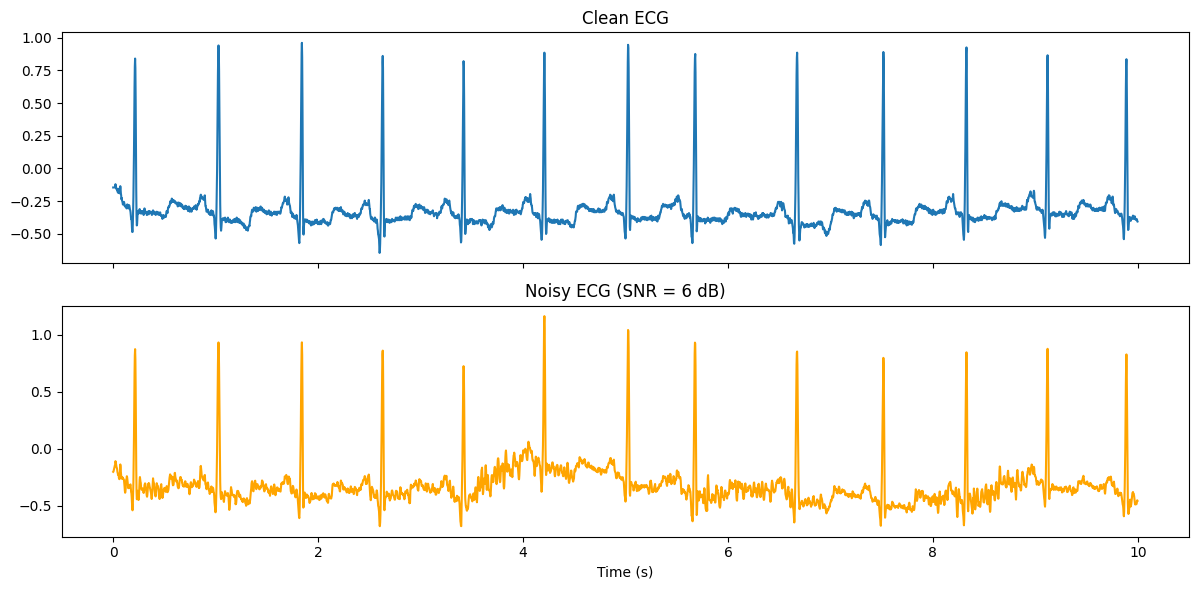

In [ ]:
# Load 10 seconds of real muscle noise from the noise database
noise_rec = wfdb.rdrecord('ma', pn_dir='nstdb', sampto=3600)
muscle = noise_rec.p_signal[:, 0]

def add_noise(clean, noise, snr_db):
    clean0 = clean - clean.mean()
    noise0 = noise - noise.mean()
    p_signal = np.mean(clean0 ** 2)
    p_noise  = np.mean(noise0 ** 2)
    scale = np.sqrt(p_signal / (p_noise * 10 ** (snr_db / 10)))
    return clean + scale * noise0

noisy = add_noise(signal, muscle, snr_db=6)

noisy = add_noise(signal, muscle, snr_db=6)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(time, signal)
axes[0].set_title("Clean ECG")
axes[1].plot(time, noisy, color="orange")
axes[1].set_title("Noisy ECG (SNR = 6 dB)")
axes[1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

SNR before: 6.00 dB
SNR after:  11.01 dB


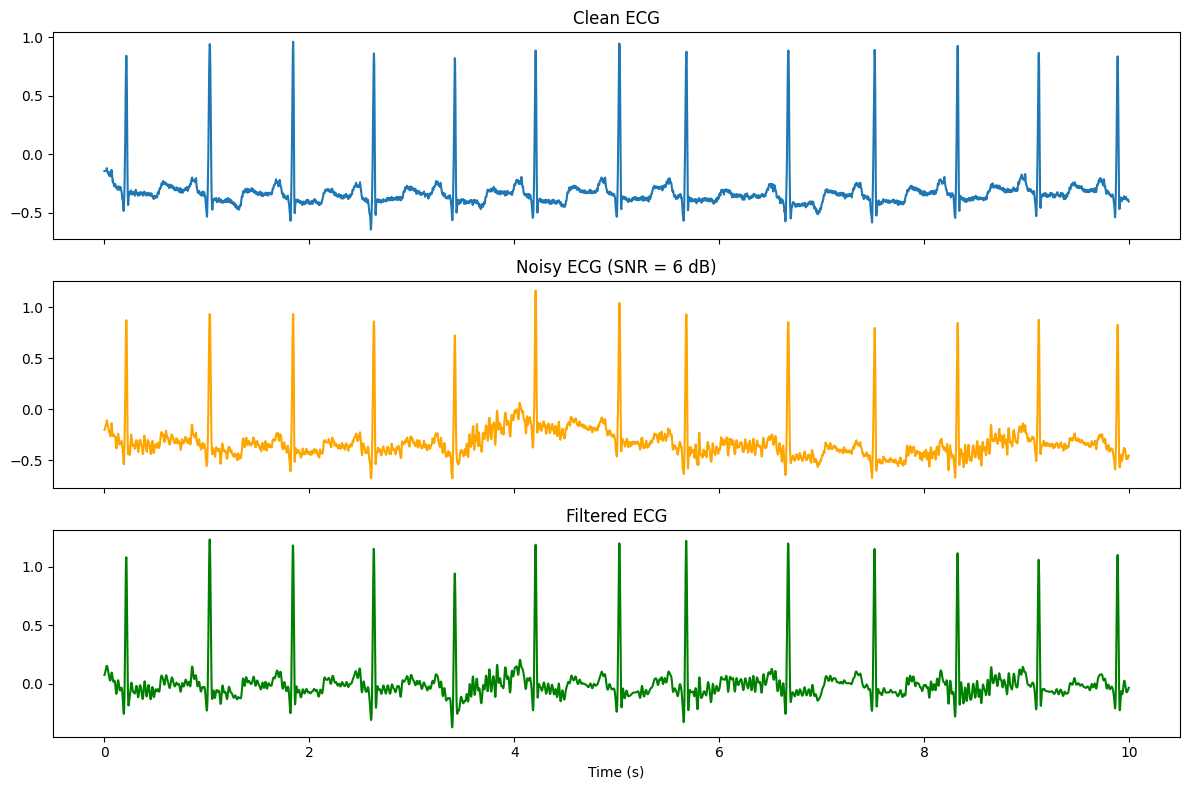

In [ ]:
from scipy.signal import butter, sosfiltfilt

fs = 360

def measure_snr(reference, x):
    ref0 = reference - reference.mean()
    x0   = x - x.mean()
    return 10 * np.log10(np.sum(ref0**2) / np.sum((x0 - ref0)**2))

def clean_ecg(x, fs, hp=0.5, lp=40.0):
    sos_hp = butter(2, hp, btype='highpass', fs=fs, output='sos')
    sos_lp = butter(4, lp, btype='lowpass',  fs=fs, output='sos')
    y = sosfiltfilt(sos_hp, x)
    y = sosfiltfilt(sos_lp, y)
    return y

filtered = clean_ecg(noisy, fs)

print(f"SNR before: {measure_snr(signal, noisy):.2f} dB")
print(f"SNR after:  {measure_snr(signal, filtered):.2f} dB")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(time, signal);                    axes[0].set_title("Clean ECG")
axes[1].plot(time, noisy, color="orange");     axes[1].set_title("Noisy ECG (SNR = 6 dB)")
axes[2].plot(time, filtered, color="green");   axes[2].set_title("Filtered ECG")
axes[2].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

Number of real beats in the answer key: 13
Clean    : {'TP': 13, 'FP': 0, 'FN': 0, 'precision': 1.0, 'recall': 1.0, 'F1': 1.0}
Noisy    : {'TP': 13, 'FP': 0, 'FN': 0, 'precision': 1.0, 'recall': 1.0, 'F1': 1.0}
Filtered : {'TP': 13, 'FP': 0, 'FN': 0, 'precision': 1.0, 'recall': 1.0, 'F1': 1.0}
answer-key beats: 13 | detected beats: 13


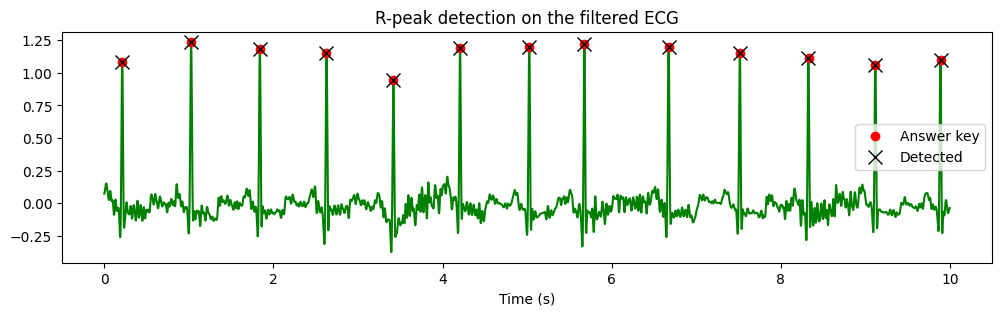

In [ ]:
from scipy.signal import butter, sosfiltfilt, find_peaks

# --- 0. Make sure the time axis is a proper NumPy array ---------------------
time = np.arange(len(filtered)) / fs

# --- 1. Load the answer key (doctors' hand-marked beats) --------------------
ann = wfdb.rdann('100', 'atr', pn_dir='mitdb', sampto=3600)
beat_symbols = set("NLRBAaJSVrFejnE/fQ")           # letters that mean "a heartbeat"
truth = np.array([s for s, sym in zip(ann.sample, ann.symbol) if sym in beat_symbols], dtype=int)
truth = truth[truth < len(filtered)]
print("Number of real beats in the answer key:", len(truth))

# --- 2. Pan-Tompkins detector ------------------------------------------------
def pan_tompkins(x, fs, thr_factor=0.35):
    sos = butter(2, [5, 15], btype='bandpass', fs=fs, output='sos')
    bp = sosfiltfilt(sos, x)                        # step 1: band-pass 5-15 Hz
    d = np.gradient(bp)                             # step 2: derivative
    sq = d ** 2                                     # step 3: squaring
    win = int(0.150 * fs)                           # 150 ms in samples
    integ = np.convolve(sq, np.ones(win) / win, mode='same')   # step 4: moving average
    thr = thr_factor * np.max(integ)                # step 5: threshold
    cand, _ = find_peaks(integ, height=thr, distance=int(0.25 * fs))
    half = int(0.08 * fs)                           # snap window: +-80 ms
    peaks = []
    for c in cand:
        a, b = max(0, c - half), min(len(x), c + half)
        peaks.append(a + np.argmax(x[a:b]))
    return np.array(peaks, dtype=int)

# --- 3. Scoring ---------------------------------------------------------------
def score(detected, truth, fs, tol_ms=75):
    tol = int(tol_ms / 1000 * fs)
    tp, used = 0, set()
    for d in detected:
        j = np.argmin(np.abs(truth - d))            # nearest real beat
        if abs(truth[j] - d) <= tol and j not in used:
            tp += 1
            used.add(j)
    fp = len(detected) - tp
    fn = len(truth) - tp
    precision = tp / (tp + fp) if tp + fp else 0
    recall    = tp / (tp + fn) if tp + fn else 0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0
    return dict(TP=tp, FP=fp, FN=fn, precision=round(precision, 3),
                recall=round(recall, 3), F1=round(f1, 3))

# --- 4. Compare the three signals ------------------------------------------
print("Clean    :", score(pan_tompkins(signal,   fs), truth, fs))
print("Noisy    :", score(pan_tompkins(noisy,    fs), truth, fs))
print("Filtered :", score(pan_tompkins(filtered, fs), truth, fs))

# --- 5. Proof plot ---------------------------------------------------------------
peaks = pan_tompkins(filtered, fs)
print("answer-key beats:", len(truth), "| detected beats:", len(peaks))

plt.figure(figsize=(12, 3))
plt.plot(time, filtered, color="green")
plt.plot(time[truth], filtered[truth], 'ro', label="Answer key")
plt.plot(time[peaks], filtered[peaks], 'kx', markersize=10, label="Detected")
plt.legend()
plt.xlabel("Time (s)")
plt.title("R-peak detection on the filtered ECG")
plt.show()

In [ ]:
from scipy.signal import butter, sosfilt, sosfilt_zi, find_peaks, correlate

# --- 1. causal filter (only uses past samples) ------------------------------
def clean_ecg(x, fs, hp=0.5, lp=40.0):
    sos_hp = butter(2, hp, btype='highpass', fs=fs, output='sos')
    sos_lp = butter(4, lp, btype='lowpass',  fs=fs, output='sos')
    y, _ = sosfilt(sos_hp, x, zi=sosfilt_zi(sos_hp) * x[0])   # zi avoids a start-up spike
    y, _ = sosfilt(sos_lp, y, zi=sosfilt_zi(sos_lp) * y[0])
    return y

# --- 2. measure the delay the filter adds (in samples) ----------------------
def filter_delay(ref, fs, hp=0.5, lp=40.0):
    y = clean_ecg(ref, fs, hp, lp)
    c = correlate(y - y.mean(), ref - ref.mean(), mode='full', method='fft')
    return max(0, int(np.argmax(c) - (len(ref) - 1)))

DELAY = filter_delay(signal, fs)
print(f"Default filter delay: {DELAY} samples = {DELAY / fs * 1000:.1f} ms")

# --- 3. SNR that ignores the constant delay ---------------------------------
def measure_snr(reference, x, delay=None):
    d = DELAY if delay is None else delay
    if d > 0:
        reference, x = reference[:-d], x[d:]
    ref0, x0 = reference - reference.mean(), x - x.mean()
    return 10 * np.log10(np.sum(ref0**2) / np.sum((x0 - ref0)**2))

# --- 4. causal Pan-Tompkins -------------------------------------------------
def pan_tompkins(x, fs, thr_factor=0.35, delay=None):
    d = DELAY if delay is None else delay
    sos = butter(2, [5, 15], btype='bandpass', fs=fs, output='sos')
    bp = sosfilt(sos, x)                                   # causal band-pass
    sq = np.diff(bp, prepend=bp[0]) ** 2                   # derivative + squaring
    win = int(0.150 * fs)
    integ = np.convolve(sq, np.ones(win) / win)[:len(sq)]  # trailing moving average
    run_max = pd.Series(integ).rolling(int(2 * fs), min_periods=1).max().values
    cand, _ = find_peaks(integ, height=thr_factor * run_max, distance=int(0.25 * fs))
    back = int(0.20 * fs)                                  # look backward only
    peaks = [max(0, c - back) + np.argmax(x[max(0, c - back):c + 1]) for c in cand]
    return np.maximum(np.array(peaks, dtype=int) - d, 0)   # undo delay for scoring

Default filter delay: 4 samples = 11.1 ms


In [ ]:
# --- 1. Load 60 s of ECG + answer key -------------------------------------
import pandas as pd
DUR = 60
N = fs * DUR                                        # number of samples in 60 s
rec60 = wfdb.rdrecord('100', pn_dir='mitdb', sampto=N)
sig60 = rec60.p_signal[:, 0]
ann60 = wfdb.rdann('100', 'atr', pn_dir='mitdb', sampto=N)
beat_symbols = set("NLRBAaJSVrFejnE/fQ")
truth60 = np.array([s for s, sym in zip(ann60.sample, ann60.symbol) if sym in beat_symbols], dtype=int)
truth60 = truth60[truth60 < N]
time60 = np.arange(N) / fs
print("Real beats in 60 s:", len(truth60))

# --- 2. Load all three noise types ------------------------------------------
noises = {}
for name in ['bw', 'em', 'ma']:
    noises[name] = wfdb.rdrecord(name, pn_dir='nstdb', sampto=N).p_signal[:, 0]

# --- 3. Sweep: every noise type x every SNR ----------------------------
results = []
for name, nz in noises.items():
    for snr in [6, 0, -6, -12]:
        noisy_k = add_noise(sig60, nz, snr)             # damage the signal
        filt_k  = clean_ecg(noisy_k, fs)                # repair with the default filter
        results.append(dict(
            noise=name,
            SNR_in=snr,
            SNR_out=round(measure_snr(sig60, filt_k), 2),
            F1_noisy=score(pan_tompkins(noisy_k, fs), truth60, fs)["F1"],
            F1_filtered=score(pan_tompkins(filt_k, fs), truth60, fs)["F1"],
        ))

baseline = pd.DataFrame(results)
baseline["SNR_gain"] = (baseline["SNR_out"] - baseline["SNR_in"]).round(2)
print(baseline)
baseline.to_csv("baseline_results.csv", index=False)

Real beats in 60 s: 74
   noise  SNR_in  SNR_out  F1_noisy  F1_filtered  SNR_gain
0     bw       6     8.90     1.000        1.000      2.90
1     bw       0     8.11     1.000        1.000      8.11
2     bw      -6     5.93     1.000        1.000     11.93
3     bw     -12     1.87     1.000        1.000     13.87
4     em       6     7.42     1.000        1.000      1.42
5     em       0     4.12     1.000        1.000      4.12
6     em      -6    -0.90     0.974        0.980      5.10
7     em     -12    -6.66     0.800        0.802      5.34
8     ma       6     6.56     1.000        1.000      0.56
9     ma       0     2.91     0.993        0.993      2.91
10    ma      -6    -2.21     0.899        0.904      3.79
11    ma     -12    -7.94     0.658        0.692      4.06


In [ ]:
def compute_features(peaks, fs, total_s=60, win_s=10):
    rows = []
    for start in range(0, total_s, win_s):
        p = peaks[(peaks >= start * fs) & (peaks < (start + win_s) * fs)]
        rr = np.diff(p) / fs * 1000                      # RR intervals in ms
        if len(rr) < 3:
            continue
        rows.append(dict(
            window=f"{start}-{start + win_s}s",
            n_beats=len(p),
            mean_RR_ms=rr.mean(),
            HR_bpm=60000 / rr.mean(),
            SDNN_ms=rr.std(ddof=1),
            RMSSD_ms=np.sqrt(np.mean(np.diff(rr) ** 2)),
        ))
    return pd.DataFrame(rows).round(1)

# a hard example: muscle noise at 0 dB, filtered, then detected
noisy60 = add_noise(sig60, noises['ma'], 0)
filt60  = clean_ecg(noisy60, fs)
peaks60 = pan_tompkins(filt60, fs)

print("Features from the answer key (ground truth):")
feat_truth = compute_features(truth60, fs)
print(feat_truth)

print("\nFeatures from our detector on the filtered noisy ECG:")
feat_ours = compute_features(peaks60, fs)
print(feat_ours)

feat_truth.to_csv("features_truth.csv", index=False)
feat_ours.to_csv("features_detected.csv", index=False)

Features from the answer key (ground truth):
   window  n_beats  mean_RR_ms  HR_bpm  SDNN_ms  RMSSD_ms
0   0-10s       13       806.3    74.4     75.6     124.0
1  10-20s       12       819.2    73.2     26.3      29.5
2  20-30s       12       808.1    74.2     27.3      30.3
3  30-40s       12       817.4    73.4     29.4      35.3
4  40-50s       13       815.7    73.6     20.0      21.1
5  50-60s       12       807.1    74.3     26.0      27.7

Features from our detector on the filtered noisy ECG:
   window  n_beats  mean_RR_ms  HR_bpm  SDNN_ms  RMSSD_ms
0   0-10s       13       806.3    74.4     75.6     124.1
1  10-20s       12       818.9    73.3     27.5      31.4
2  20-30s       12       807.8    74.3     27.7      30.8
3  30-40s       13       749.3    80.1    149.0     176.3
4  40-50s       13       815.7    73.6     19.3      19.7
5  50-60s       12       807.1    74.3     25.9      28.0


2026-09-30 07:34:04,712 - pyswarms.single.global_best - INFO - Optimize for 30 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.7}
pyswarms.single.global_best: 100%|██████████|30/30, best_cost=0.0642
2026-09-30 07:34:14,112 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.06419112346839705, best pos: [ 1.82147975 21.09256126  0.25624195]



Best settings -> high-pass: 1.82 Hz | low-pass: 21.1 Hz | threshold: 0.26


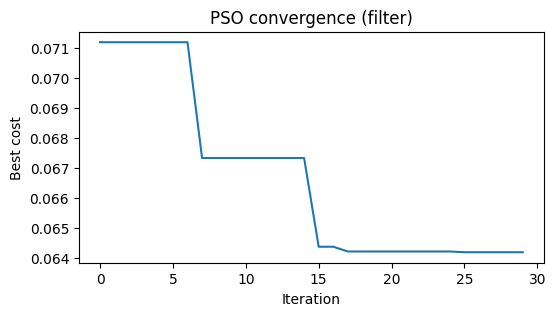

   noise  SNR_in  SNR_out_default  SNR_out_PSO  F1_default  F1_PSO
0     bw       6             8.90         4.52       1.000   1.000
1     bw       0             8.11         4.50       1.000   1.000
2     bw      -6             5.93         4.42       1.000   1.000
3     bw     -12             1.87         4.10       1.000   1.000
4     em       6             7.42         4.11       1.000   1.000
5     em       0             4.12         3.03       1.000   1.000
6     em      -6            -0.90         0.28       0.980   0.961
7     em     -12            -6.66        -4.30       0.802   0.766
8     ma       6             6.56         4.24       1.000   1.000
9     ma       0             2.91         3.41       0.993   0.993
10    ma      -6            -2.21         1.08       0.904   0.925
11    ma     -12            -7.94        -3.18       0.692   0.727

Average F1  default: 0.948 | PSO: 0.948
Average SNR default: 2.34 | PSO: 2.18


In [ ]:
import pyswarms as ps

np.random.seed(0)

# scenario we tune on: muscle noise at -6 dB (hard)
noisy_tune = add_noise(sig60, noises['ma'], -6)

def evaluate(hp, lp, thr, noisy_sig, ref, truth_idx):
    f = clean_ecg(noisy_sig, fs, hp=hp, lp=lp)
    if 'filter_delay' in globals():                 # use the delay helper if this notebook has it
        d = filter_delay(ref, fs, hp, lp)
        f1 = score(pan_tompkins(f, fs, thr_factor=thr, delay=d), truth_idx, fs)["F1"]
        snr = measure_snr(ref, f, delay=d)
    else:
        f1 = score(pan_tompkins(f, fs, thr_factor=thr), truth_idx, fs)["F1"]
        snr = measure_snr(ref, f)
    return f1, snr

# PSO fitness (lower is better): mostly detection error, plus a small reward for higher SNR
def cost(params):
    out = []
    for hp, lp, thr in params:
        f1, snr = evaluate(hp, lp, thr, noisy_tune, sig60, truth60)
        out.append((1 - f1) - 0.01 * snr)
    return np.array(out)

bounds = (np.array([0.1, 20.0, 0.1]),      # lower: hp, lp, thr
          np.array([2.0, 100.0, 0.7]))     # upper: hp, lp, thr

optimizer = ps.single.GlobalBestPSO(
    n_particles=20, dimensions=3,
    options={'c1': 1.5, 'c2': 1.5, 'w': 0.7},
    bounds=bounds)

best_cost, best_pos = optimizer.optimize(cost, iters=30)
hp_best = best_pos[0]
lp_best = best_pos[1]
thr_best = best_pos[2]
print(f"\nBest settings -> high-pass: {hp_best:.2f} Hz | low-pass: {lp_best:.1f} Hz | threshold: {thr_best:.2f}")

# learning curve
plt.figure(figsize=(6, 3))
plt.plot(optimizer.cost_history)
plt.xlabel("Iteration")
plt.ylabel("Best cost")
plt.title("PSO convergence (filter)")
plt.show()

# default vs tuned across ALL noise types and SNR levels
rows = []
for name, nz in noises.items():
    for snr_in in [6, 0, -6, -12]:
        nsy = add_noise(sig60, nz, snr_in)
        f1_d, snr_d = evaluate(0.5, 40.0, 0.35, nsy, sig60, truth60)
        f1_t, snr_t = evaluate(hp_best, lp_best, thr_best, nsy, sig60, truth60)
        rows.append(dict(noise=name, SNR_in=snr_in,
                         SNR_out_default=round(snr_d, 2), SNR_out_PSO=round(snr_t, 2),
                         F1_default=f1_d, F1_PSO=f1_t))

comparison = pd.DataFrame(rows)
print(comparison)
comparison.to_csv("default_vs_pso.csv", index=False)
print("\nAverage F1  default:", comparison.F1_default.mean().round(3),
      "| PSO:", comparison.F1_PSO.mean().round(3))
print("Average SNR default:", comparison.SNR_out_default.mean().round(2),
      "| PSO:", comparison.SNR_out_PSO.mean().round(2))

In [ ]:
!zip results.zip *.csv report.log
from google.colab import files
files.download('results.zip')

updating: baseline_results.csv (deflated 46%)
updating: default_vs_pso.csv (deflated 47%)
updating: features_detected.csv (deflated 32%)
updating: features_truth.csv (deflated 33%)
updating: report.log (deflated 91%)
updating: arrhythmia_eval.csv (deflated 48%)
updating: attempt_log.csv (deflated 40%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   t_end_s     HR   irr  danger
0      3.0  74.48  0.01   16.79
1      4.0  75.26  0.01   16.79
2      5.0  76.06  0.00   16.79
3      6.0  79.70  0.10   27.99
4      7.0  73.06  0.17   50.00
5      8.0  72.24  0.17   50.00
Record 100 -> max danger: 50.0 | alerts: 0
False alerts before onset: 0
Alert latency after onset: 1.5 s


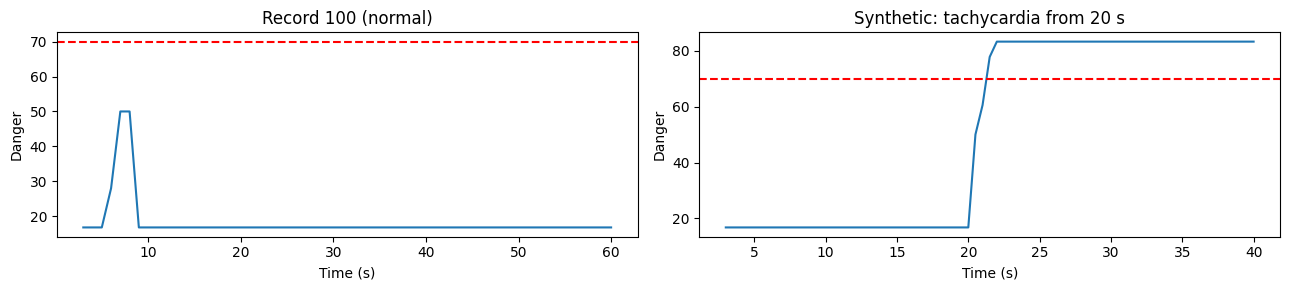

In [ ]:
# ================= FUZZY CLASSIFIER (plain NumPy, Mamdani style) =================
# Every number you may want to change (or PSO may tune) is in CFG / FUZZY.
FUZZY = dict(
    hr_low        = (0, 0, 40, 55),        # trapezoid points (a, b, c, d), bpm
    hr_normal     = (45, 60, 100, 130),
    hr_high       = (100, 150, 300, 300),
    irr_regular   = (0, 0, 0.05, 0.12),    # irregularity = std(RR)/mean(RR)
    irr_irregular = (0.08, 0.20, 1, 1),
    out_low       = (0, 0, 20, 45),        # output shapes on the 0-100 danger scale
    out_med       = (25, 50, 50, 75),
    out_high      = (55, 80, 100, 100),
)
# failsafe=True: a window with fewer than 2 detected beats raises the alert (score 100)
CFG = dict(win_s=3, step_s=1, alert_thr=70, fuzzy=FUZZY, failsafe=True)

def detect(x):
    """Filter + beat detection, using this notebook's delay helper if it exists."""
    f = clean_ecg(x, fs)
    if 'filter_delay' in globals():
        return pan_tompkins(f, fs, delay=filter_delay(x, fs, 0.5, 40.0))
    return pan_tompkins(f, fs)

def trap(x, a, b, c, d):
    """Trapezoid membership: 0 below a, rises to 1 at b, flat to c, falls to 0 at d."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    up   = np.ones_like(x) if b <= a else np.clip((x - a) / (b - a), 0, 1)
    down = np.ones_like(x) if d <= c else np.clip((d - x) / (d - c), 0, 1)
    return np.minimum(up, down)

Y = np.arange(0, 101)                      # the danger scale, 0..100

def fuzzy_danger(hr, irr, F=FUZZY):
    """Heart rate and irregularity (arrays) -> danger score 0-100 (array)."""
    hr, irr = np.atleast_1d(hr), np.atleast_1d(irr)
    # 1. fuzzify: number -> degree of membership
    hr_low, hr_norm, hr_high = (trap(hr, *F[k]) for k in ('hr_low', 'hr_normal', 'hr_high'))
    reg, irg = trap(irr, *F['irr_regular']), trap(irr, *F['irr_irregular'])
    o_low, o_med, o_high = (trap(Y, *F[k]) for k in ('out_low', 'out_med', 'out_high'))
    # 2. rule strengths (AND = min)
    r1, r2 = hr_high, hr_low
    r3, r4 = np.minimum(hr_norm, reg), np.minimum(hr_norm, irg)
    # 3. clip each rule's output shape, then combine with max
    agg = np.maximum.reduce([np.minimum(r1[:, None], o_high),
                             np.minimum(r2[:, None], o_med),
                             np.minimum(r3[:, None], o_low),
                             np.minimum(r4[:, None], o_med)])
    # 4. defuzzify: centroid (balance point) of the combined shape
    area = agg.sum(axis=1)
    return np.where(area > 0, (agg * Y).sum(axis=1) / np.maximum(area, 1e-9), 0.0)

def danger_timeline(peaks, fs, total_s, cfg=CFG):
    """Danger score for every sliding window. t_end_s = when that decision is available."""
    starts = np.arange(0, total_s - cfg['win_s'] + 1e-9, cfg['step_s'])
    hr_v, irr_v = np.full(len(starts), np.nan), np.full(len(starts), np.nan)
    for i, s in enumerate(starts):
        p = peaks[(peaks >= s * fs) & (peaks < (s + cfg['win_s']) * fs)]
        if len(p) >= 2:                               # need at least 2 beats
            rr = np.diff(p) / fs
            hr_v[i], irr_v[i] = 60 / rr.mean(), rr.std() / rr.mean()
    danger, ok = np.full(len(starts), np.nan), ~np.isnan(hr_v)
    danger[ok] = fuzzy_danger(hr_v[ok], irr_v[ok], cfg['fuzzy'])
    if cfg.get('failsafe', True):
        danger[~ok] = 100.0                           # too few beats to judge: fail safe, raise the alert
    return pd.DataFrame(dict(t_end_s=starts + cfg['win_s'], HR=hr_v, irr=irr_v, danger=danger))

# ---------- TEST 1: normal rhythm (record 100) -> expect NO alerts ----------
peaks60 = detect(sig60)
tl = danger_timeline(peaks60, fs, 60)
print(tl.round(2).head(6))
print("Record 100 -> max danger:", round(np.nanmax(tl.danger), 1),
      "| alerts:", int((tl.danger >= CFG['alert_thr']).sum()))

# ---------- TEST 2: synthetic tachycardia starting at t = 20 s ----------
t1 = np.arange(1.0, 20.0, 60 / 75)                    # 75 bpm
t2 = np.arange(20.0, 40.0, 60 / 170)                  # 170 bpm from 20 s
synth = (np.concatenate([t1, t2]) * fs).astype(int)
tl2 = danger_timeline(synth, fs, 40, dict(CFG, step_s=0.5))
first = tl2.t_end_s[(tl2.danger >= CFG['alert_thr']) & (tl2.t_end_s > 20)]
print("False alerts before onset:", int(((tl2.danger >= CFG['alert_thr']) & (tl2.t_end_s <= 20)).sum()))
print("Alert latency after onset:", round(first.min() - 20, 1) if len(first) else "NO ALERT", "s")

fig, ax = plt.subplots(1, 2, figsize=(13, 3))
ax[0].plot(tl.t_end_s, tl.danger); ax[0].set_title("Record 100 (normal)")
ax[1].plot(tl2.t_end_s, tl2.danger); ax[1].set_title("Synthetic: tachycardia from 20 s")
for a in ax:
    a.axhline(CFG['alert_thr'], color='r', ls='--'); a.set_xlabel("Time (s)"); a.set_ylabel("Danger")
plt.tight_layout(); plt.show()

In [ ]:
LETHAL = ('(VT', '(VFL', '(VF')
episodes = []                                   # (record, rhythm, start_sample, end_sample)

for r in wfdb.get_record_list('mitdb'):
    a = wfdb.rdann(r, 'atr', pn_dir='mitdb')
    idx = [i for i, s in enumerate(a.symbol) if s == '+']       # rhythm-change marks
    for k, i in enumerate(idx):
        label = a.aux_note[i].strip('\x00').strip()
        if label in LETHAL:
            end = a.sample[idx[k + 1]] if k + 1 < len(idx) else a.sample[-1]
            episodes.append((r, label, int(a.sample[i]), int(end)))

ep = pd.DataFrame(episodes, columns=['record', 'rhythm', 'start', 'end'])
ep['start_s'] = (ep.start / fs).round(1)
ep['dur_s']   = ((ep.end - ep.start) / fs).round(1)
print(ep[['record', 'rhythm', 'start_s', 'dur_s']])

2026-09-30 07:35:08,171 - wfdb.io._url - INFO - GET https://physionet.org/content/mitdb/1.0.0/: 200 0-None/None
2026-09-30 07:35:08,397 - wfdb.io._url - INFO - GET https://physionet.org/files/mitdb/1.0.0/RECORDS: 200 0-192/192
2026-09-30 07:35:09,517 - wfdb.io._url - INFO - GET https://physionet.org/content/mitdb/1.0.0/: 200 0-None/None
2026-09-30 07:35:09,758 - wfdb.io._url - INFO - GET https://physionet.org/files/mitdb/1.0.0/100.atr: 200 0-4558/4558
2026-09-30 07:35:10,001 - wfdb.io._url - INFO - GET https://physionet.org/files/mitdb/1.0.0/100.hea: 200 0-143/143
2026-09-30 07:35:11,208 - wfdb.io._url - INFO - GET https://physionet.org/content/mitdb/1.0.0/: 200 0-None/None
2026-09-30 07:35:11,448 - wfdb.io._url - INFO - GET https://physionet.org/files/mitdb/1.0.0/101.atr: 200 0-3768/3768
2026-09-30 07:35:11,678 - wfdb.io._url - INFO - GET https://physionet.org/files/mitdb/1.0.0/101.hea: 200 0-131/131
2026-09-30 07:35:13,349 - wfdb.io._url - INFO - GET https://physionet.org/content/mit

   record rhythm  start_s  dur_s
0     106    (VT    176.7    2.0
1     200    (VT    108.9    2.5
2     200    (VT    629.9    1.7
3     200    (VT    945.4    2.8
4     200    (VT   1070.6    1.7
..    ...    ...      ...    ...
62    233    (VT    587.8    1.8
63    233    (VT   1348.2    1.8
64    233    (VT   1352.1    1.8
65    233    (VT   1367.6    1.8
66    233    (VT   1753.9    1.8

[67 rows x 4 columns]


cached episodes: 10
Tuned [hr_start, hr_width, irr_start, irr_width, alert_thr]: [1.07325e+02 1.05620e+01 5.30000e-02 2.92000e-01 4.83970e+01]


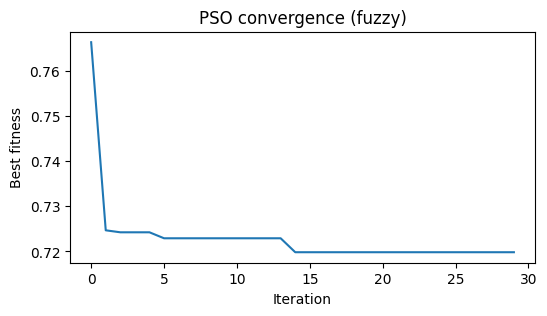

                    attempt  split  fitness   sens   spec late_or_missed  \
0  Attempt 1: default fuzzy  train    1.138  0.411  0.902            1/5   
1  Attempt 1: default fuzzy   test    0.835  0.729  0.873            1/5   
2      Attempt 2: PSO fuzzy  train    0.720  0.932  0.497            0/5   
3      Attempt 2: PSO fuzzy   test    0.624  1.000  0.552            0/5   

   FA_per_hour  
0        222.2  
1        332.0  
2        393.7  
3        416.6  


In [ ]:
import pyswarms as ps
import logging; logging.disable(logging.INFO)

# ---------- 1. Cache: download each episode ONCE, detect beats ONCE ----------
PAD = 60
cache = []
for _, e in ep[ep.dur_s >= 3].head(10).iterrows():
    end = min(e.end, e.start + 90 * fs)
    n = wfdb.rdheader(e.record, pn_dir='mitdb').sig_len
    s0, s1 = max(0, e.start - PAD * fs), min(n, end + PAD * fs)
    x = wfdb.rdrecord(e.record, pn_dir='mitdb', sampfrom=s0, sampto=s1).p_signal[:, 0]
    pk = pan_tompkins(clean_ecg(x, fs), fs)              # fixed, constraint-safe filter
    cache.append(dict(record=e.record, rhythm=e.rhythm, peaks=pk, total_s=len(x) / fs,
                      ep_a=(e.start - s0) / fs, ep_b=(end - s0) / fs))
print("cached episodes:", len(cache))
train, test = cache[0::2], cache[1::2]                    # split by episode

# ---------- 2. Per-episode statistics (with the corrected latency) ----------
def episode_stats(c, cfg):
    cfg = dict(cfg, step_s=0.5)
    tl = danger_timeline(c['peaks'], fs, c['total_s'], cfg)
    win_a = tl.t_end_s - cfg['win_s']
    ov = (np.minimum(tl.t_end_s, c['ep_b']) - np.maximum(win_a, c['ep_a'])).clip(lower=0)
    pos, neg = ov >= cfg['win_s'] / 2, ov == 0            # window inside / outside the episode
    alert = tl.danger >= cfg['alert_thr']
    hit = tl.t_end_s[alert & (ov > 0)]                    # ONLY windows overlapping the episode
    lat = (hit.min() - c['ep_a']) if len(hit) else np.nan
    rising = alert & ~alert.shift(1, fill_value=False)
    return dict(TP=int((alert & pos).sum()), FN=int((~alert & pos).sum()),
                TN=int((~alert & neg).sum()), FP=int((alert & neg).sum()),
                FAE=int((rising & neg).sum()), neg_h=neg.sum() * cfg['step_s'] / 3600, lat=lat)

def evaluate(cfg, items):
    r = pd.DataFrame([episode_stats(c, cfg) for c in items])
    sens = r.TP.sum() / max(r.TP.sum() + r.FN.sum(), 1)
    spec = r.TN.sum() / max(r.TN.sum() + r.FP.sum(), 1)
    late = int((~(r.lat <= 3)).sum())                     # NaN or > 3 s counts as late/missed
    return dict(sens=sens, spec=spec, late=late, n=len(r),
                fa_h=r.FAE.sum() / max(r.neg_h.sum(), 1e-9))

# ---------- 3. Fitness (lower is better) -- weights are the knobs ----------
W = dict(sens=1.0, spec=0.5, late=0.5, fa=0.2)
def J(cfg, items):
    m = evaluate(cfg, items)
    return (W['sens'] * (1 - m['sens']) + W['spec'] * (1 - m['spec'])
            + W['late'] * m['late'] / m['n'] + W['fa'] * min(m['fa_h'] / 100, 2)), m

# ---------- 4. Particle -> fuzzy configuration ----------
def make_cfg(p):
    hr_a, hr_w, irr_a, irr_w, thr = p
    F = dict(FUZZY)
    F['hr_normal']     = (45, 60, hr_a, hr_a + hr_w)
    F['hr_high']       = (hr_a, hr_a + hr_w, 300, 300)
    F['irr_regular']   = (0, 0, 0.6 * irr_a, irr_a)
    F['irr_irregular'] = (irr_a, irr_a + irr_w, 1, 1)
    return dict(CFG, fuzzy=F, alert_thr=thr)

def pso_cost(P):
    return np.array([J(make_cfg(p), train)[0] for p in P])

# ---------- 5. Run PSO (fitness on the TRAIN episodes only) ----------
np.random.seed(0)
lb = np.array([90, 5, 0.04, 0.02, 40])
ub = np.array([140, 60, 0.20, 0.30, 90])
opt = ps.single.GlobalBestPSO(n_particles=20, dimensions=5,
                              options={'c1': 1.5, 'c2': 1.5, 'w': 0.7}, bounds=(lb, ub))
best_J, best_p = opt.optimize(pso_cost, iters=30, verbose=False)
print("Tuned [hr_start, hr_width, irr_start, irr_width, alert_thr]:", best_p.round(3))

plt.figure(figsize=(6, 3)); plt.plot(opt.cost_history)
plt.xlabel("Iteration"); plt.ylabel("Best fitness"); plt.title("PSO convergence (fuzzy)"); plt.show()

# ---------- 6. Attempt table: default vs tuned, train and test ----------
rows = []
for name, cfg in [('Attempt 1: default fuzzy', CFG), ('Attempt 2: PSO fuzzy', make_cfg(best_p))]:
    for split, items in [('train', train), ('test', test)]:
        j, m = J(cfg, items)
        rows.append(dict(attempt=name, split=split, fitness=round(j, 3), sens=round(m['sens'], 3),
                         spec=round(m['spec'], 3), late_or_missed=f"{m['late']}/{m['n']}",
                         FA_per_hour=round(m['fa_h'], 1)))
attempts = pd.DataFrame(rows); print(attempts)
attempts.to_csv("attempt_log.csv", index=False)

In [ ]:
import time, tracemalloc
tuned = make_cfg(best_p)

# ---- A. Normal rhythm sanity check (record 100): should raise no alerts ----
pk100 = pan_tompkins(clean_ecg(sig60, fs), fs)
for name, cfg in [('default', CFG), ('tuned', tuned)]:
    tl = danger_timeline(pk100, fs, 60, cfg)
    print(f"Record 100 [{name}] -> max danger {np.nanmax(tl.danger):.1f} | alert windows: {int((tl.danger >= cfg['alert_thr']).sum())}")

# ---- B. Jitter: how far detected peaks are from the doctors' marks ----
def jitter_ms(det, truth, tol_ms=75):
    tol, err = int(tol_ms / 1000 * fs), []
    for d in det:
        j = np.argmin(np.abs(truth - d))
        if abs(truth[j] - d) <= tol:
            err.append((d - truth[j]) / fs * 1000)
    err = np.array(err)
    return err.std(), np.abs(err).mean()

for label, x in [('clean', sig60),
                 ('muscle noise -6 dB', add_noise(sig60, noises['ma'], -6)),
                 ('baseline wander -6 dB', add_noise(sig60, noises['bw'], -6))]:
    sd, mae = jitter_ms(pan_tompkins(clean_ecg(x, fs), fs), truth60)
    print(f"Jitter [{label}]: std {sd:.1f} ms | mean abs error {mae:.1f} ms")

# ---- C. Runtime and memory for 60 s of ECG ----
tracemalloc.start(); t0 = time.perf_counter()
_pk = pan_tompkins(clean_ecg(sig60, fs), fs)
_tl = danger_timeline(_pk, fs, 60, tuned)
dt = time.perf_counter() - t0
_, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
print(f"Runtime: {dt*1000:.0f} ms for 60 s of ECG ({dt/60*1000:.1f} ms per second of signal) | peak memory {peak/1e6:.2f} MB")

Record 100 [default] -> max danger 50.0 | alert windows: 0
Record 100 [tuned] -> max danger 50.0 | alert windows: 3
Jitter [clean]: std 1.0 ms | mean abs error 0.3 ms
Jitter [muscle noise -6 dB]: std 9.0 ms | mean abs error 1.8 ms
Jitter [baseline wander -6 dB]: std 1.0 ms | mean abs error 0.4 ms
Runtime: 23 ms for 60 s of ECG (0.4 ms per second of signal) | peak memory 1.30 MB


In [ ]:
def qrs_amp(x, pk, w=int(0.3 * fs), s=int(0.05 * fs)):
    return np.array([x[max(0, p - s):p + s].max() - np.median(x[max(0, p - w):p + w]) for p in pk])

base = qrs_amp(sig60, truth60)
for name, kw in [('final filter 0.5-40 Hz', dict()),
                 ('earlier PSO filter', dict(hp=hp_best, lp=lp_best))]:
    r = np.median(qrs_amp(clean_ecg(sig60, fs, **kw), truth60) / base)
    print(f"QRS amplitude kept, {name}: {r*100:.1f}%")

QRS amplitude kept, final filter 0.5-40 Hz: 91.6%
QRS amplitude kept, earlier PSO filter: 63.4%


## Round 1: Fuzzy Signal Classifier + PSO

Pipeline: ECG (MIT-BIH) → Butterworth filter 0.5–40 Hz → Pan-Tompkins beat detection → heart rate and beat irregularity over 3 s windows → fuzzy classifier → danger score (0–100) → alert when the score reaches the threshold.

Representation:each PSO particle is 5 numbers: [HR-high start, HR-high width, irregular start, irregular width, alert threshold]. Trapezoid points are built as "start + width", so they can never cross. The filter is fixed at 0.5–40 Hz to preserve QRS amplitude and the ST segment.

Fuzzy rules:high HR → high danger; low HR → medium; normal HR and regular rhythm → low; normal HR and irregular rhythm → medium. (min for AND, max to combine, centroid to defuzzify.)

PSO:20 particles, 30 iterations, inertia 0.7, own-best and swarm-best pulls 1.5 each. Chosen because sensitivity, false alarms and alert delay are not differentiable, and PSO needs few parameters and little compute. Fuzzy rules stay readable and cheap to run.

Fitness (minimize): 1.0·(1 − sensitivity) + 0.5·(1 − specificity) + 0.5·(late or missed episodes ÷ total) + 0.2·min(false alarms per hour ÷ 100, 2). Missing a real event costs the most.

Parameters used:Pan-Tompkins threshold 0.35, window 3 s. Tuned: HR-high start 102.8 bpm, width 41.2; irregular start 0.164, width 0.083;